# EDA of the Master Dataset and Feature Log Transformation

In this notebook, we perform a visual analysis of the distributions of all numerical features in the final master dataset,  
as well as create log-transformed versions of key metrics for further analysis and modeling.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

In [3]:
df = pd.read_csv("../../data/clean/master_dataset_2015_2020.csv")
df.head()

,year,poverty_percent,region,income_per_capita,real_income,nominal_wage,real_wage,children_percent,elderly_percent,working_age_percent,...,production_per_capita,poverty_welfare_ratio,birth_rate_per_1000,infant_mortality_rural_rate,infant_mortality_urban_rate,disabled_18_30_rate,disabled_31_40_rate,disabled_41_50_rate,disabled_51_60_rate,disabled_60_plus_rate
0,2015,8.5,Белгородская область,28043.0,99.3,25456.0,93.2,43.4,11.8,42.3,...,448.058152,0.752212,11.895859,2.351097,3.806538,3.626420,6.629519,10.233659,22.036901,95.349584
1,2016,8.1,Белгородская область,29799.0,100.8,27091.0,100.8,43.4,11.8,42.3,...,478.465681,0.686441,11.454064,2.085627,4.171253,3.613722,6.606304,10.197823,21.959734,95.015697
2,2017,7.8,Белгородская область,30342.0,99.1,29066.0,104.5,43.4,11.8,44.8,...,1038.799178,0.475610,10.020973,2.249719,2.845233,4.036161,6.805140,10.728634,24.144082,99.374206
3,2018,7.5,Белгородская область,30778.0,98.7,31852.0,106.8,44.8,12.9,42.3,...,1184.515803,0.480769,9.470209,2.304791,2.793686,3.700754,6.644624,10.249968,22.549401,95.918499
4,2019,7.8,Белгородская область,32352.0,100.6,34615.0,104.0,0.0,0.0,0.0,...,1240.585480,0.565217,8.718105,1.212306,1.742690,3.498617,6.516510,10.066210,21.199561,93.373011


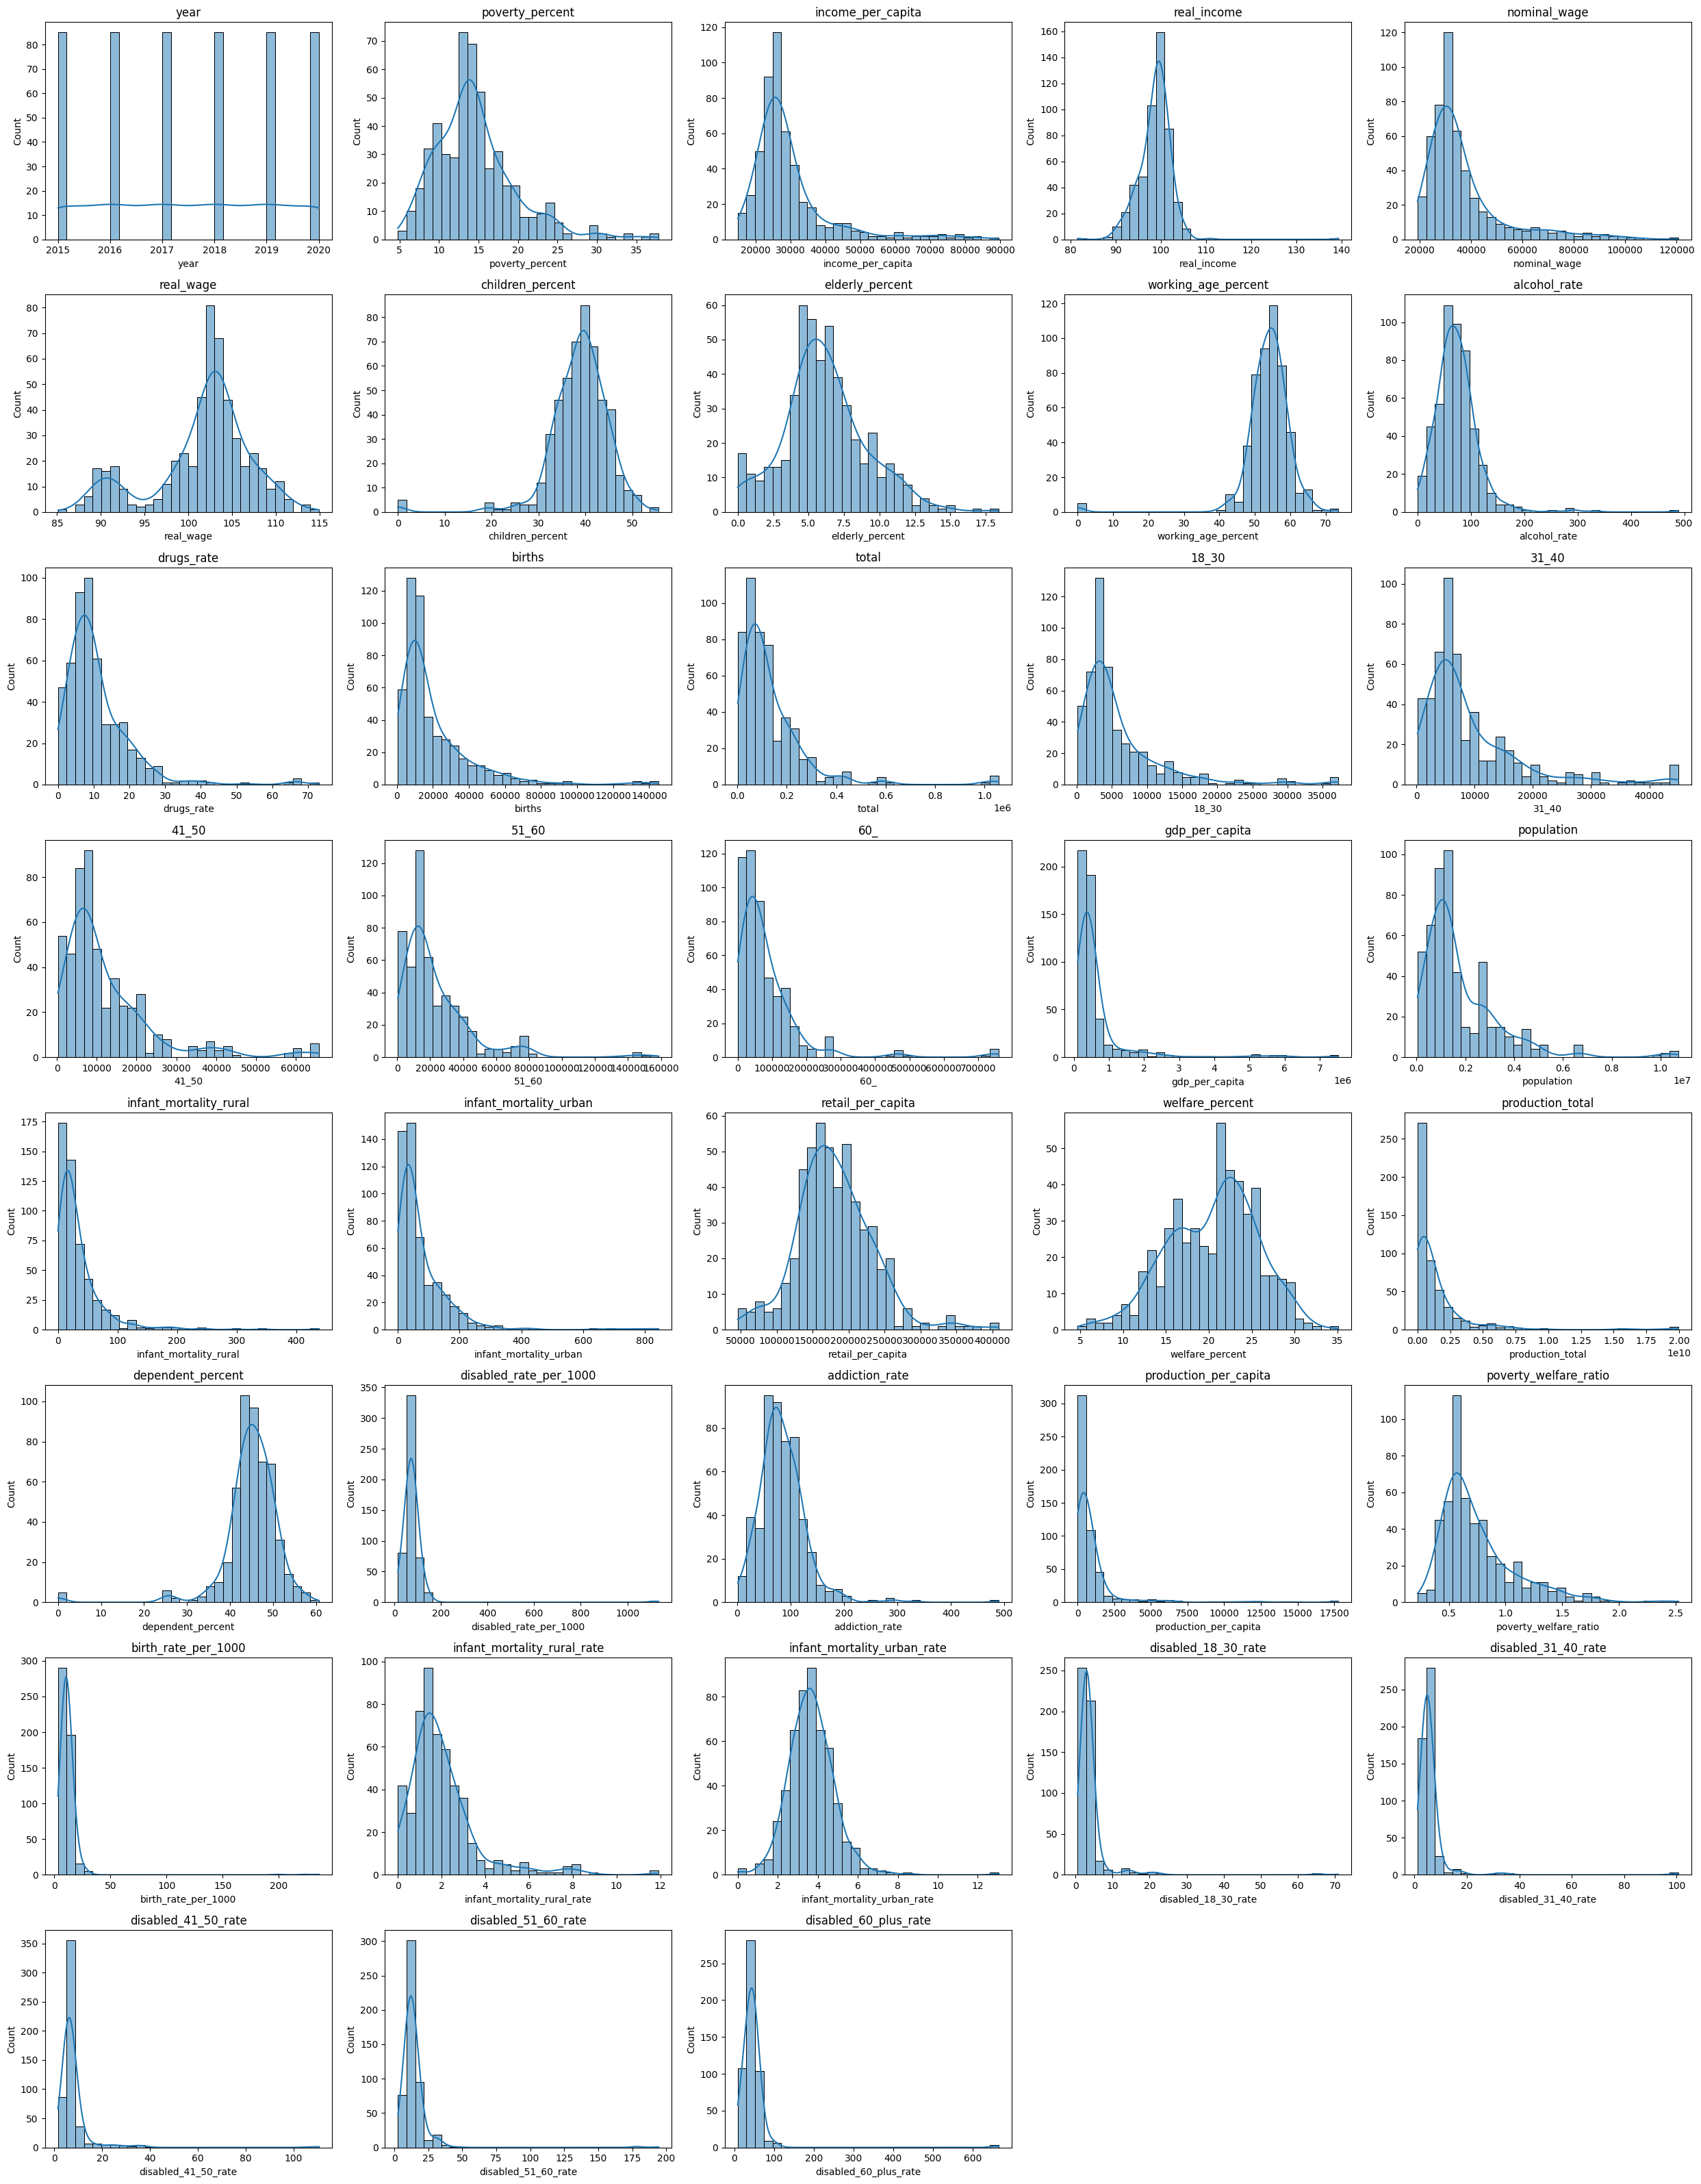

In [4]:
# Select all numerical features
num_cols = df.select_dtypes(include='number').columns

# Set grid parameters for plots
n_cols = 5
n_rows = math.ceil(len(num_cols) / n_cols)

# Plot histograms
plt.figure(figsize=(5 * n_cols, 4 * n_rows))
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

In [5]:
log_features = [
    # Economy
    'income_per_capita', 'real_income', 'nominal_wage', 'real_wage',
    'gdp_per_capita', 'retail_per_capita', 'production_total', 'production_per_capita',

    # Population & births
    'births', 'population', 'birth_rate_per_1000',

    # Disability (absolute + normalized)
    'total', '18_30', '31_40', '41_50', '51_60', '60_',
    'disabled_rate_per_1000',
    'disabled_18_30_rate', 'disabled_31_40_rate',
    'disabled_41_50_rate', 'disabled_51_60_rate', 'disabled_60_plus_rate',

    # Health & social issues
    'alcohol_rate', 'drugs_rate', 'addiction_rate',
    'infant_mortality_rural', 'infant_mortality_urban',
    'infant_mortality_rural_rate', 'infant_mortality_urban_rate'
]

for col in log_features:
    df[f"log_{col}"] = np.log1p(df[col])

In [6]:
df.to_csv("../../data/clean/log_master_dataset_2015_2020.csv", index=False)

## Conclusions on Log Transformation

Most numerical features in the dataset have a **right-skewed distribution** and **large scale**, making them sensitive to outliers and negatively affecting model performance.

### Log-transformed features:
- **Economy**: `income_per_capita`, `real_income`, `nominal_wage`, `real_wage`, `gdp_per_capita`, `retail_per_capita`, `production_total`, `production_per_capita`
- **Population**: `births`, `population`, `birth_rate_per_1000`
- **Disability**: `total`, `18_30`, `31_40`, `41_50`, `51_60`, `60_`, `disabled_rate_per_1000`, `disabled_18_30_rate`, `disabled_31_40_rate`, `disabled_41_50_rate`, `disabled_51_60_rate`, `disabled_60_plus_rate`
- **Health**: `alcohol_rate`, `drugs_rate`, `addiction_rate`, `infant_mortality_rural`, `infant_mortality_urban`, `infant_mortality_rural_rate`, `infant_mortality_urban_rate`


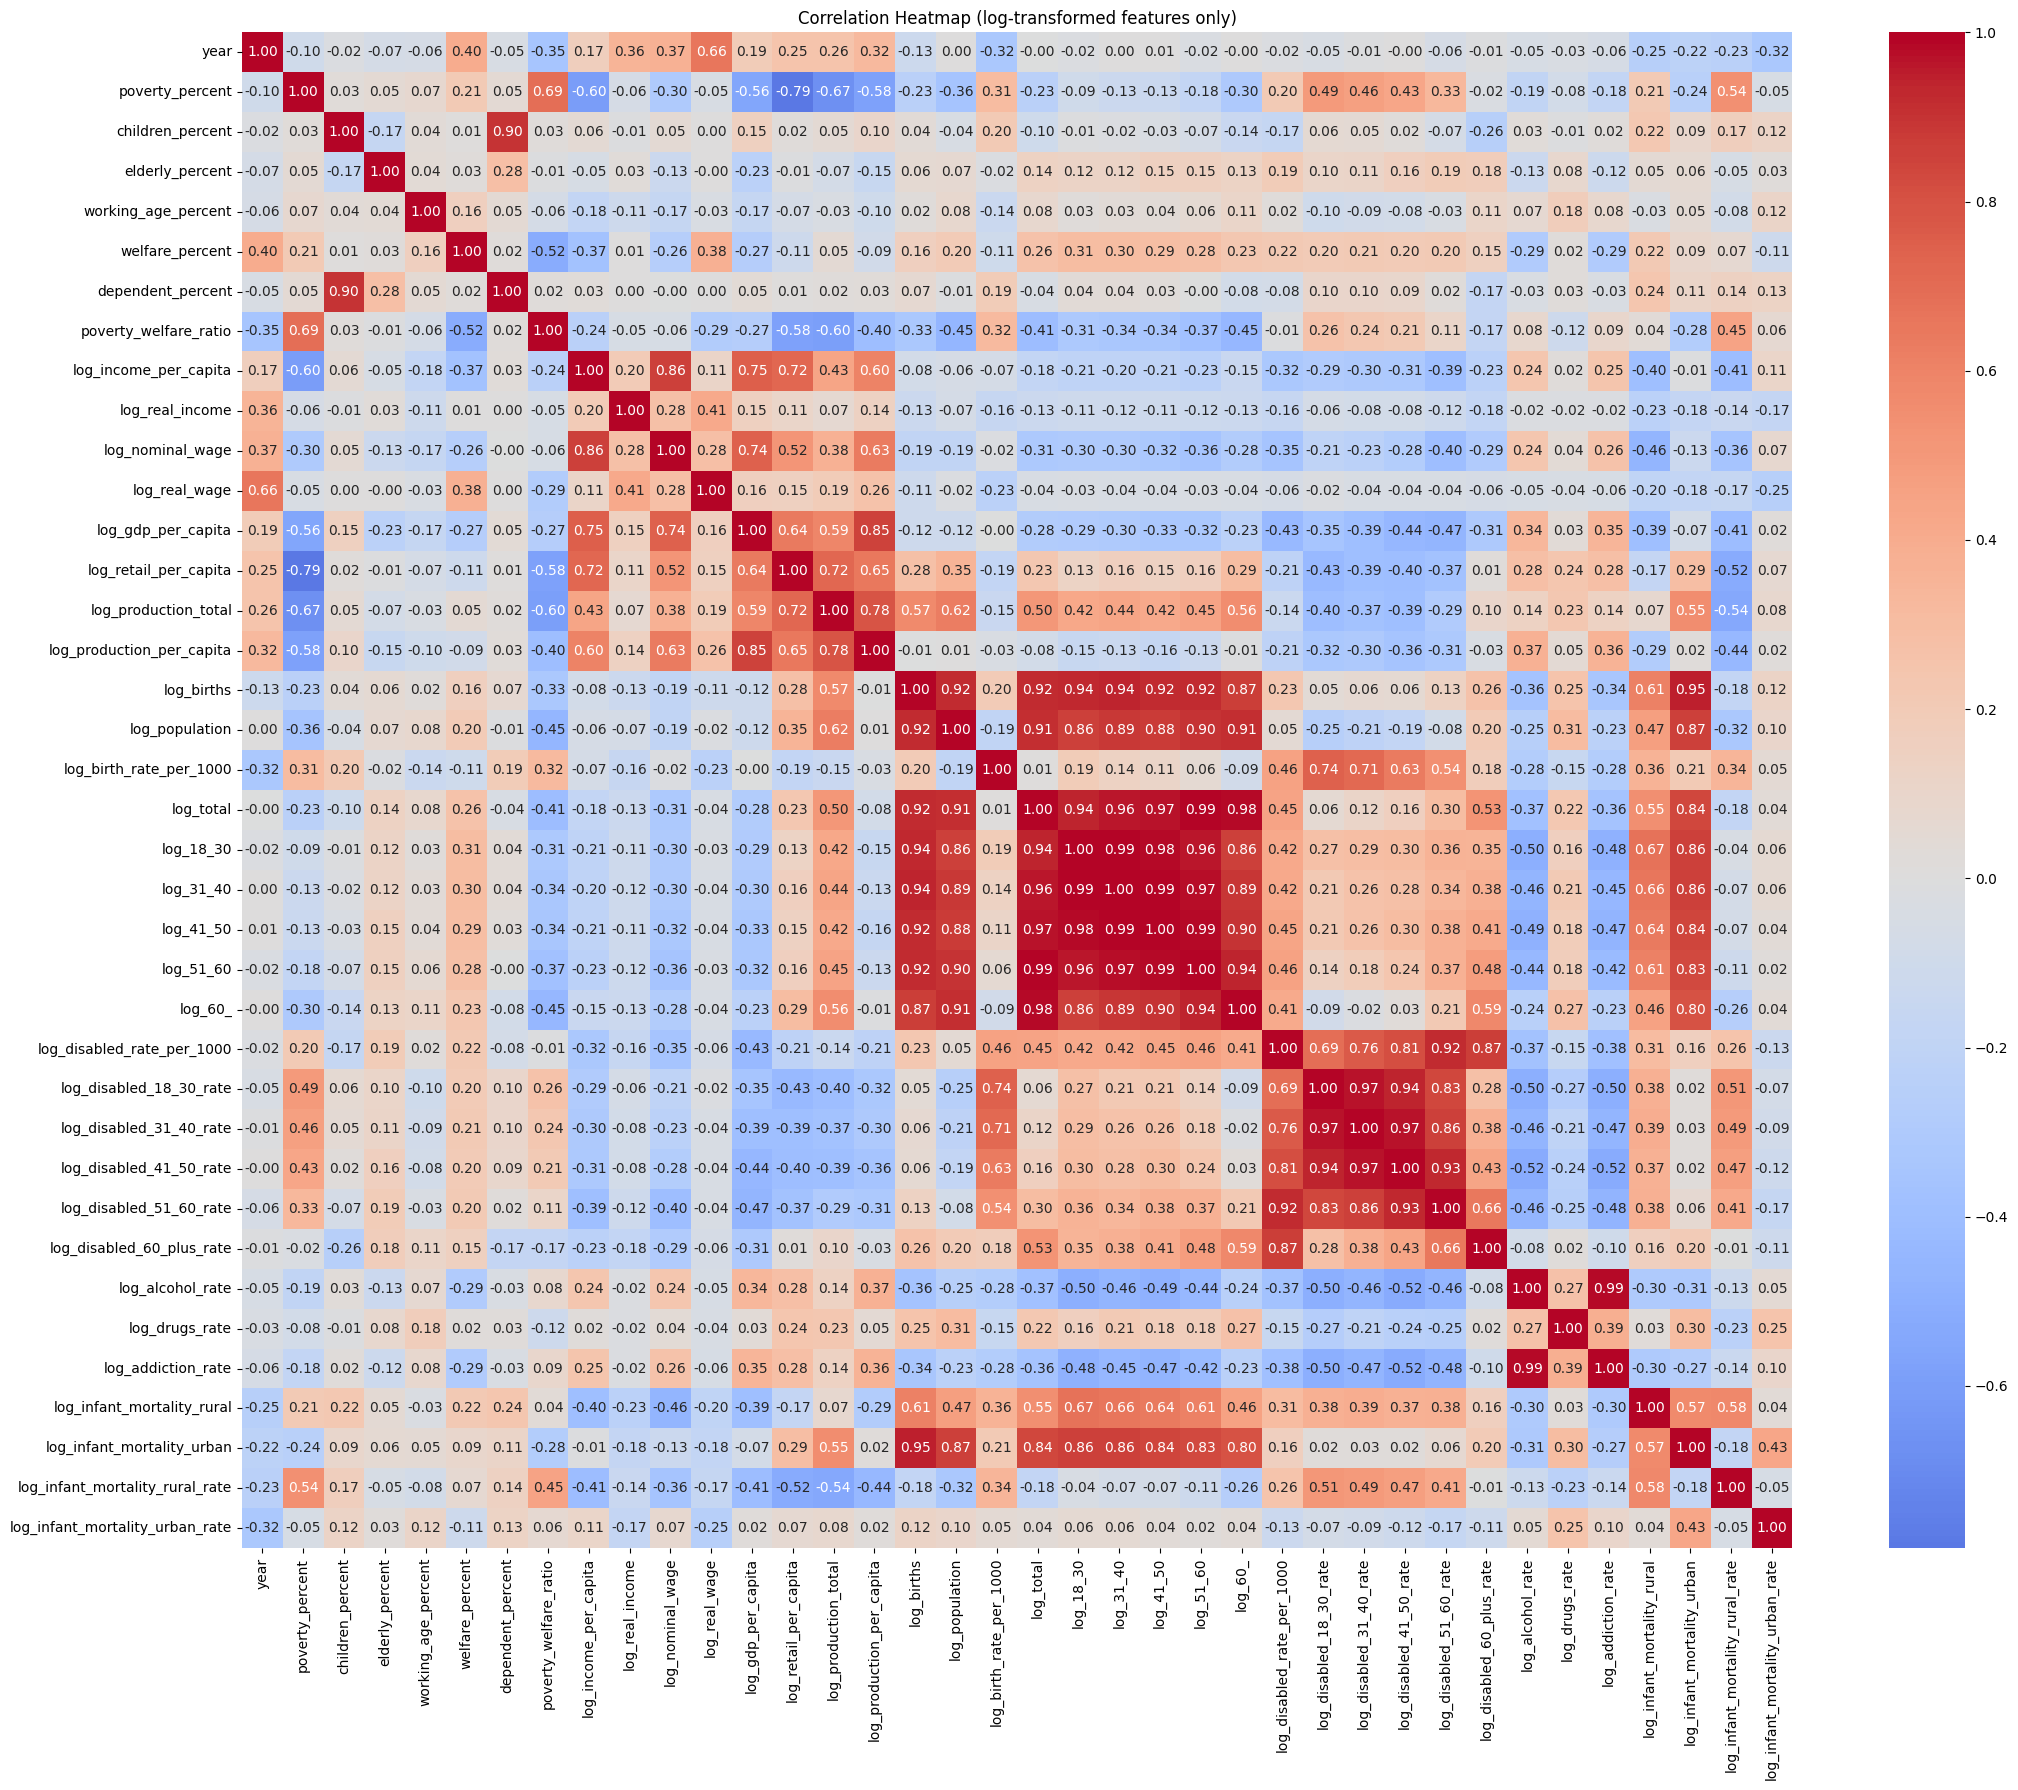

In [7]:
# Select log-transformed features and remove original ones
log_features = [col for col in df.columns if col.startswith("log_")]
original_features = [col.replace("log_", "") for col in log_features if col.replace("log_", "") in df.columns]
df_filtered = df.drop(columns=original_features)

# Keep only numerical features
numeric_df = df_filtered.select_dtypes(include=["number"])

# Compute correlation matrix
correlation_matrix = numeric_df.corr()

# Plot heatmap with values
plt.figure(figsize=(22, 18))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation Heatmap (log-transformed features only)")
plt.tight_layout()
plt.show()


## Comparison of Normalized vs Non-Normalized Features by Correlation with Poverty

### Goal
To check whether normalization (e.g., dividing by population) strengthens the correlation between features and the target variable `poverty_percent`.

---

### Key Findings

- **Normalized features almost always show stronger (in absolute value) correlation with poverty.**
- Examples of significant increases:
  - `disabled_41_50_rate` → absolute increase: **+0.54**
  - `disabled_18_30_rate` → **+0.48**
  - `infant_mortality_rural_rate` → **+0.42**

---

### Why This Matters

- **Absolute values (e.g., `total`, `births`) depend on region size.**  
  → This masks the true relationships.
- **Normalization removes the scale effect**, allowing fair comparison across regions.
- **Normalized features better reflect per-capita social burden.**

---

### Conclusion
Normalization by population is **justified and useful** — it strengthens signals, reduces distortion, and makes the data more interpretable. These features should be preferred for modeling and clustering.

## Analysis of Feature Correlations with Poverty

### Goal
To understand which factors are most strongly associated with poverty levels (`poverty_percent`) and how to interpret them for analysis, modeling, and social policy.

---

### 1. Income and Consumption
| Feature                  | Correlation |
|--------------------------|------------|
| `log_retail_per_capita` | –0.79      |
| `retail_per_capita`     | –0.73      |
| `log_income_per_capita` | –0.60      |
| `income_per_capita`     | –0.50      |

**Conclusion:**  
Higher income and per-capita consumption are associated with lower poverty levels. These are the strongest correlations and reflect fundamental economic relationships.

---

### 2. Production and Economic Activity
| Feature                     | Correlation |
|-----------------------------|------------|
| `log_production_total`     | –0.67      |
| `log_production_per_capita`| –0.58      |
| `log_gdp_per_capita`       | –0.56      |

**Conclusion:**  
Higher production and regional GDP (especially per capita) are linked to lower poverty. Economically active regions tend to have lower poverty rates.

---

### 3. Social Support and Its Effectiveness
| Feature                | Correlation |
|------------------------|------------|
| `poverty_welfare_ratio`| +0.69      |
| `welfare_percent`      | +0.21      |

**Conclusion:**  
The `poverty_welfare_ratio` reflects how much poverty "outpaces" social support. High values may indicate ineffective policy.  
`welfare_percent` alone shows weak correlation, likely because it is a reactive measure.

---

### 4. Healthcare and Vulnerability
| Feature                          | Correlation |
|----------------------------------|------------|
| `log_infant_mortality_rural_rate`| +0.54      |
| `log_disabled_41_50_rate`        | +0.43      |
| `log_disabled_51_60_rate`        | +0.33      |

**Conclusion:**  
Poor health conditions and weak healthcare infrastructure are often associated with higher poverty. These features are strong indicators of vulnerability.

---

### 5. Demographics
| Feature             | Correlation |
|---------------------|------------|
| `children_percent`  | +0.03      |
| `elderly_percent`   | +0.05      |
| `dependent_percent` | +0.05      |

**Conclusion:**  
Population structure does not directly affect poverty.  
Its influence is likely indirect, through economic or fiscal pressure.

---

### 6. Alcohol, Drugs, and Addictions
| Feature              | Correlation |
|----------------------|------------|
| `log_alcohol_rate`   | –0.19      |
| `log_addiction_rate` | –0.18      |
| `log_drugs_rate`     | –0.08      |

**Conclusion:**  
These relationships are weak and potentially reversed:  
regions with better healthcare systems may simply detect more cases. Interpretation should be cautious.

---

### Overall Summary

Most strongly associated with poverty:
- Income and consumption  
- Economic activity  
- Vulnerability indicators (disability, mortality)  
- Poverty-to-welfare ratio  

Less significant:
- Population structure  
- Alcohol and drug indicators  

These insights help focus on the most important factors for modeling and policy decisions.